<a href="https://colab.research.google.com/github/T-Ph525/StyleGAN2/blob/main/Copy_of_Stable_Diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [1]:
!pip install diffusers==0.8.0
!pip install "jax[cuda12_local]==0.4.23" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
!pip install transformers scipy ftfy accelerate
!pip install "ipywidgets>=7,<8"
!wget https://raw.githubusercontent.com/huggingface/diffusers/4674fdf807cdefd4db1758067c0207872d805f8c/examples/inference/image_to_image.py
!wget https://i.ibb.co/3458s9H/sample.png

Looking in links: https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
--2024-07-21 07:13:50--  https://raw.githubusercontent.com/huggingface/diffusers/4674fdf807cdefd4db1758067c0207872d805f8c/examples/inference/image_to_image.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6808 (6.6K) [text/plain]
Saving to: ‘image_to_image.py.3’

image_to_image.py.3 100%[===================>]   6.65K  --.-KB/s    in 0s      

2024-07-21 07:13:50 (84.6 MB/s) - ‘image_to_image.py.3’ saved [6808/6808]

--2024-07-21 07:13:50--  https://i.ibb.co/3458s9H/sample.png
Resolving i.ibb.co (i.ibb.co)... 172.96.160.210, 172.96.160.168, 104.194.8.120, ...
Connecting to i.ibb.co (i.ibb.co)|172.96.160.210|:443... connected.
HTTP request sent, awaiting response... 200 OK
L

In [2]:
from google.colab import output
output.enable_custom_widget_manager()

In [3]:
from pathlib import Path
from PIL import Image
import torch
from diffusers import StableDiffusionPipeline
import requests
import getpass
from io import BytesIO
from image_to_image import StableDiffusionImg2ImgPipeline, preprocess

def image_grid(imgs, rows, cols):
    assert len(imgs) == rows*cols

    w, h = imgs[0].size
    grid = Image.new('RGB', size=(cols*w, rows*h))
    grid_w, grid_h = grid.size

    for i, img in enumerate(imgs):
        grid.paste(img, box=(i%cols*w, i//cols*h))
    return grid
cache_drive = False

# (optional) Mount Google Drive as Cache Directory
If you're not doing this you will be required to manually enter your HuggingFace Access Token every time you freshly start this colab notebook
### NOTE: Needs 2.6 GB storage space in your Google drive


In [4]:
from google.colab import drive
drive.mount('/content/drive/')

cache_dir = "/content/drive/MyDrive/weights" #@param {type:"string"}
cache_drive = True

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


# Load txt2img Model

In [5]:
if not cache_drive:
    cache_dir = "/content/weights"
flag = False
Enable_NSFW = True #@param {type:"boolean"}
for p in Path(cache_dir).rglob("*"):
    if p.name == "model_index.json":
        flag = True
        print(f"Cache dir Found: {p.parent}")
        break
if flag:
    print("Loading the model, Please Wait...")
    pipe = StableDiffusionPipeline.from_pretrained(pretrained_model_name_or_path=p.parent, revision="fp16", torch_dtype=torch.float16, use_auth_token=False)
else:
    token = getpass.getpass("Cache not Found, Enter Your HuggingFace Access token Here:")
    token = token.strip()
    print("Loading the model, Please Wait...")
    pipe = StableDiffusionPipeline.from_pretrained("CompVis/stable-diffusion-v1-4", cache_dir=cache_dir, revision="fp16", torch_dtype=torch.float16, use_auth_token=token)
print("Model Loaded Successfully!")
if Enable_NSFW:
    pipe.safety_checker = lambda images, **kwargs: (images, False)
pipe = pipe.to("cuda")

Cache dir Found: /content/drive/MyDrive/weights/models--CompVis--stable-diffusion-v1-4/snapshots/2880f2ca379f41b0226444936bb7a6766a227587
Loading the model, Please Wait...


/usr/local/lib/python3.10/dist-packages/transformers/models/clip/feature_extraction_clip.py:28: FutureWarning: The class CLIPFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use CLIPImageProcessor instead.
  warnings.warn(


Model Loaded Successfully!


# Run Stable Diffusion txt2img

  0%|          | 0/104 [00:00<?, ?it/s]

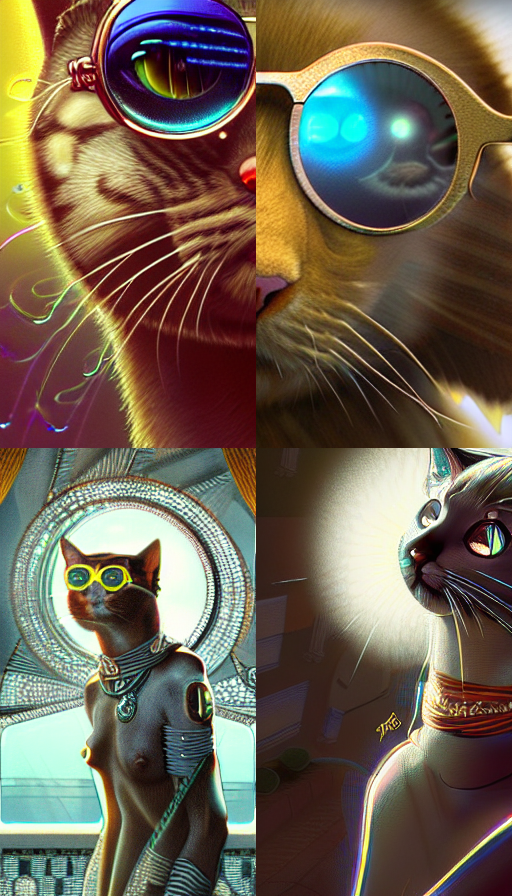

In [9]:
#@title # Stable Diffusion txt2img
prompt = "A Cyborg cat wearing a sun glass, tone mapped, shiny, intricate, cinematic lighting, highly detailed, digital painting, artstation, concept art, smooth, sharp focus, illustration, art by terry moore and greg rutkowski and alphonse mucha" #@param {type:"string"}

#@markdown Height of the Image:
H = 448 #@param {type:"slider", min:256, max:1024, step:64}

#@markdown Width of the Image:
W = 256 #@param {type:"slider", min:256, max:1024, step:64}

#@markdown Number of images to generate:
n = 4 #@param {type:"integer"}

#@markdown Seed:
seed = 3 #@param {type:"integer"}

#@markdown Steps to generate the image(lower number->faster but crappier image):
steps = 103 #@param {type:"slider", min:1, max:150, step:1}

#@markdown How strong your text prompt should influence the image(default 7.5)
guidance_scale = 6.6 #@param {type:"slider", min:6, max:15, step:0.1}

#@markdown ### Display Settings
show_grid = True #@param {type:"boolean"}
#@markdown If you have `show_grid` enabled, make sure `n = rows*columns`
#@markdown , Ignore if you have `show_grid` disabled.

prompt = [prompt] * n
generator = torch.Generator("cuda").manual_seed(seed)
with torch.autocast("cuda"):
    images = pipe(prompt, num_inference_steps=steps, generator=generator, height=H, width=W, guidance_scale=guidance_scale).images
    del generator

if show_grid:
    rows = 2 #@param {type:"integer"}
    columns = 2 #@param {type:"integer"}
    grid = image_grid(images, rows=rows, cols=columns)
    display(grid)

## View Individual images
You can view individual images by just running `images[i]` (where `i` is the index)
For example: You can view the first image by running `images[0]`,
Second image by running `images[1]`, third image by running `images[2]`...

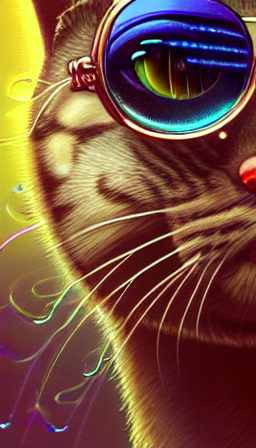

In [10]:
images[0]

# Load img2img Model

In [11]:
if not cache_drive:
    cache_dir = "/content/weights"
flag = False
Enable_NSFW = True #@param {type:"boolean"}
for p in Path(cache_dir).rglob("*"):
    if p.name == "model_index.json":
        flag = True
        print(f"Cache Found: {p.parent}")
        break
if flag:
    print("Loading the model, Please Wait...")
    pipe = StableDiffusionImg2ImgPipeline.from_pretrained(pretrained_model_name_or_path=p.parent, revision="fp16", torch_dtype=torch.float16, use_auth_token=False)
else:
    token = getpass.getpass("Cache not Found, Enter Your HuggingFace Access token Here:")
    token = token.strip()
    print("Loading the model, Please Wait...")
    pipe = StableDiffusionImg2ImgPipeline.from_pretrained("CompVis/stable-diffusion-v1-4", cache_dir=cache_dir, revision="fp16", torch_dtype=torch.float16, use_auth_token=token)
print("Model Loaded Successfully!")
if Enable_NSFW:
    pipe.safety_checker = lambda images, **kwargs: (images, False)
pipe = pipe.to("cuda")

Cache Found: /content/drive/MyDrive/weights/models--CompVis--stable-diffusion-v1-4/snapshots/2880f2ca379f41b0226444936bb7a6766a227587
Loading the model, Please Wait...


AttributeError: 'PNDMScheduler' object has no attribute 'set_format'

# Run Stable Diffusion img2img

In [ ]:
#@title # Stable Diffusion img2img
prompt = "Wall-E, tone mapped, shiny, intricate, cinematic lighting, highly detailed, digital painting, artstation, concept art, smooth, sharp focus, illustration, art by terry moore and greg rutkowski and alphonse mucha" #@param {type:"string"}
path_to_input_image = "/content/sample.png" #@param {type:"string"}

#@markdown Height of the Image:
H = 512 #@param {type:"slider", min:256, max:1024, step:64}

#@markdown Width of the Image:
W = 512 #@param {type:"slider", min:256, max:1024, step:64}


#@markdown Seed:
seed = 3 #@param {type:"integer"}

#@markdown Steps to generate the image(lower number->faster but crappier image):
steps = 70 #@param {type:"slider", min:1, max:150, step:1}

#@markdown How strong your text prompt should influence the image(default 7.5)
guidance_scale = 7.5 #@param {type:"slider", min:6, max:15, step:0.1}

input_image = Image.open(path_to_input_image).convert("RGB")
input_image = input_image.resize((W, H))
input_image_array = preprocess(input_image)

generator = torch.Generator("cuda").manual_seed(seed)
with torch.autocast("cuda"):
    images = pipe(prompt, init_image=input_image_array, num_inference_steps=steps, generator=generator, guidance_scale=guidance_scale)["sample"]
    del generator

#@markdown ### Display Settings
show_grid = True #@param {type:"boolean"}
if show_grid:
    new_grid = [input_image, images[0]]
    grid = image_grid(new_grid,rows=1,cols=2)
    display(grid)
else:
    display(images[0])

In [ ]:
images[0]